<a href="https://colab.research.google.com/github/FC-Andrade/Syndecan_4-Ag73/blob/main/Pipeline_NMR_e_MD_Syndecan_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install MDAnalysis scikit-learn scipy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import distances
from MDAnalysis.analysis import pca
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde
import seaborn as sns

In [ ]:

# ==================================================
# 1. UPLOAD DOS ARQUIVOS
# ==================================================

from google.colab import files
import MDAnalysis as mda

print("Faça upload do arquivo de topologia (.gro)")
uploaded_top = files.upload()

topology = list(uploaded_top.keys())[0]

print("Faça upload das três trajetórias (.xtc)")
uploaded_traj = files.upload()

trajectories = list(uploaded_traj.keys())

print("Faça upload do ensemble NMR (.pdb)")
uploaded_nmr = files.upload()

nmr_file = list(uploaded_nmr.keys())[0]

Faça upload do arquivo de topologia (.gro)


Saving topology.gro to topology.gro
Faça upload das três trajetórias (.xtc)


Saving rep1_noPBC.xtc to rep1_noPBC.xtc
Saving rep2_noPBC.xtc to rep2_noPBC.xtc
Saving rep3_noPBC.xtc to rep3_noPBC.xtc
Faça upload do ensemble NMR (.pdb)


Saving syndecan4_NMR__ensemble.pdb to syndecan4_NMR__ensemble.pdb


In [ ]:
# ==================================================
# 2. CARREGAMENTO DAS ESTRUTURAS
# ==================================================

replicas = [mda.Universe(topology, traj) for traj in trajectories]

# ensemble NMR
u_nmr = mda.Universe(nmr_file)

selection = "protein and name CA"

print("Arquivos carregados com sucesso.")
print("Topologia:", topology)
print("Trajetórias:", trajectories)
print("NMR:", nmr_file)

ValueError: The topology and XTC trajectory files don't have the same number of atoms!
Topology number of atoms 68128
Trajectory: rep1_noPBC.xtc Number of atoms 49536

In [ ]:
# ==============================
# 3. ALINHAMENTO GLOBAL
# ==============================

ref = replicas[0]

for u in replicas:
    align.AlignTraj(u, ref, select=selection, in_memory=True).run()


NameError: name 'replicas' is not defined

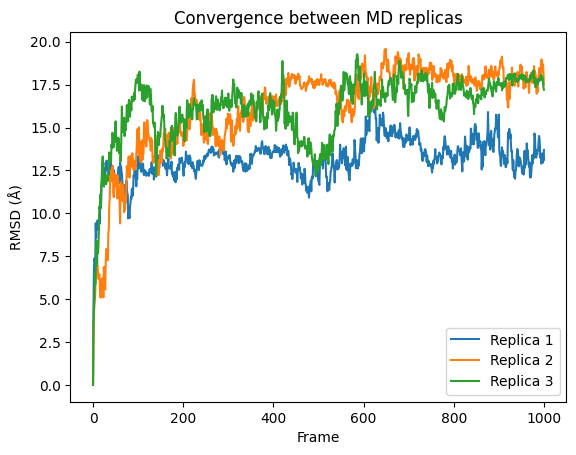

In [ ]:
# ==================================================
# 4. VERIFICAÇÃO DE CONVERGÊNCIA ENTRE RÉPLICAS
# ==================================================

rmsd_curves = []

for i, u in enumerate(replicas):

    R = rms.RMSD(u, u, select=selection)
    R.run()

    rmsd_curve = R.results.rmsd[:,2]
    rmsd_curves.append(rmsd_curve)

    plt.plot(rmsd_curve, label=f"Replica {i+1}")

plt.xlabel("Frame")
plt.ylabel("RMSD (Å)")
plt.title("Convergence between MD replicas")
plt.legend()

plt.savefig("Fig_replicas_convergence.png", dpi=600)

plt.show()

NMR atoms: 56
MD atoms usados: 56
MD atoms usados: 56
MD atoms usados: 56


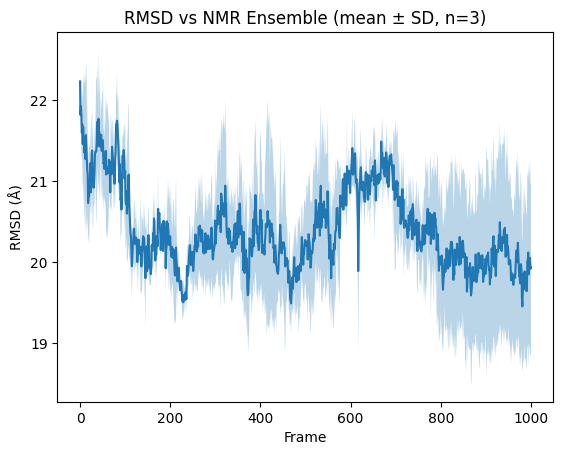

In [ ]:
# ==================================================
# 5. RMSD vs ENSEMBLE NMR
# ==================================================

# Selecionar todos os CA da proteína
ref_ca = u_nmr.select_atoms("name CA")
print("NMR atoms:", len(ref_ca))

rmsd_replicas = []

for u in replicas:

    # selecionar CA da trajetória
    mobile_ca = u.select_atoms("name CA")

    # pegar apenas os primeiros 56 (removendo o ligante)
    mobile_atoms = mobile_ca[:56]
    ref_atoms = ref_ca[:56]

    print("MD atoms usados:", len(mobile_atoms))

    rmsd_models = []

    for ts in u_nmr.trajectory:

        R = rms.RMSD(
            mobile_atoms,
            ref_atoms,
            ref_frame=ts.frame
        )

        R.run()

        rmsd_models.append(R.results.rmsd[:,2])

    rmsd_models = np.array(rmsd_models)

    rmsd_mean_model = rmsd_models.mean(axis=0)

    rmsd_replicas.append(rmsd_mean_model)

rmsd_replicas = np.array(rmsd_replicas)

mean_rmsd = rmsd_replicas.mean(axis=0)
std_rmsd = rmsd_replicas.std(axis=0)

# ==============================
# Plot
# ==============================

plt.figure()

plt.plot(mean_rmsd)

plt.fill_between(
    range(len(mean_rmsd)),
    mean_rmsd - std_rmsd,
    mean_rmsd + std_rmsd,
    alpha=0.3
)

plt.xlabel("Frame")
plt.ylabel("RMSD (Å)")
plt.title("RMSD vs NMR Ensemble (mean ± SD, n=3)")

plt.savefig("Fig1_RMSD_replicas.png", dpi=600)

plt.show()

In [ ]:
u = replicas[0]

print("Total atoms:", len(u.atoms))
print("Total residues:", len(u.residues))

print("First residues:")
for r in u.residues[:20]:
    print(r.resid, r.resname)

print("Last residues:")
for r in u.residues[-20:]:
    print(r.resid, r.resname)

Total atoms: 49536
Total residues: 16257
First residues:
1 ARG
2 LYS
3 ARG
4 LEU
5 GLN
6 VAL
7 GLN
8 LEU
9 SER
10 ILE
11 ARG
12 THR
1 ARG
2 MET
3 LYS
4 LYS
5 LYS
6 ASP
7 GLU
8 GLY
Last residues:
16198 TIP3
16199 TIP3
16200 TIP3
16201 TIP3
16202 TIP3
16203 TIP3
16204 TIP3
16205 TIP3
16206 TIP3
16207 TIP3
16208 TIP3
16209 TIP3
16210 TIP3
16211 TIP3
16212 TIP3
16213 TIP3
16214 TIP3
16215 TIP3
16216 TIP3
16217 TIP3


Chain A CA: 56
Chain A CA: 56
Chain A CA: 56


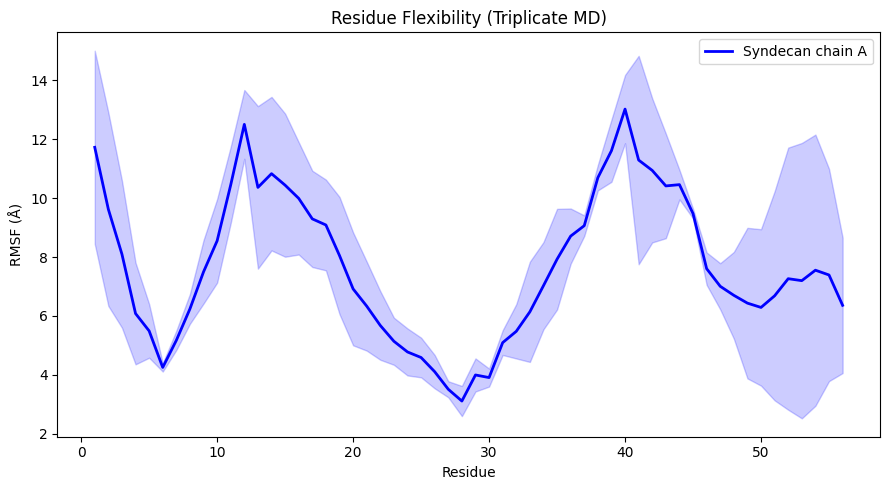

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis.rms import RMSF

rmsf_A = []
rmsf_B = []
rmsf_L = []

for u in replicas:

    # todas as proteínas CA
    protein_ca = u.select_atoms("protein and name CA")

    # separar cadeias A e B
    chainA = protein_ca[:56]


    print("Chain A CA:", len(chainA))

    rmsf_A.append(RMSF(chainA).run().results.rmsf)


rmsf_A = np.array(rmsf_A)


mean_A = rmsf_A.mean(axis=0)
std_A = rmsf_A.std(axis=0)



resS = np.arange(1,57)

plt.figure(figsize=(9,5))

# Syndecan A
plt.plot(resS, mean_A, color="blue", linewidth=2, label="Syndecan chain A")
plt.fill_between(resS, mean_A-std_A, mean_A+std_A, color="blue", alpha=0.2)


plt.xlabel("Residue")
plt.ylabel("RMSF (Å)")
plt.title("Residue Flexibility (Triplicate MD)")

plt.legend()
plt.tight_layout()

plt.savefig("RMSF_complex.png", dpi=600)

plt.show()

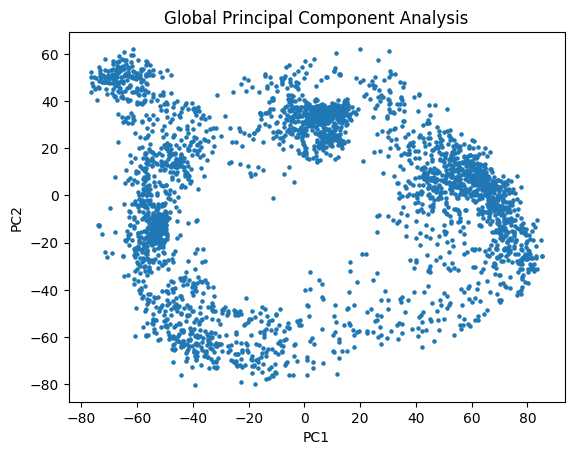

In [ ]:
# ==================================================
# 7. PCA GLOBAL (todas réplicas)
# ==================================================

coords_all = []

for u in replicas:

    protein = u.select_atoms(selection)

    for ts in u.trajectory:
        coords_all.append(protein.positions.flatten())

coords_all = np.array(coords_all)

# PCA manual via SVD

coords_mean = coords_all.mean(axis=0)

coords_centered = coords_all - coords_mean

U, S, Vt = np.linalg.svd(coords_centered, full_matrices=False)

pc = np.dot(coords_centered, Vt.T[:,0:2])

plt.figure()
plt.scatter(pc[:,0], pc[:,1], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Global Principal Component Analysis")
plt.savefig("Fig3_PCA.png", dpi=600)
plt.show()


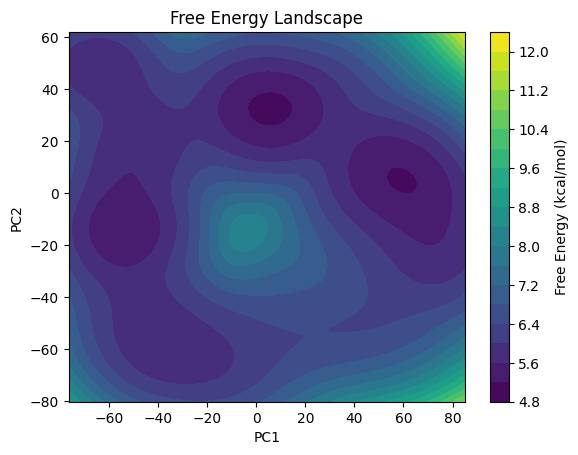

In [ ]:
# ==============================
# 8. FREE ENERGY LANDSCAPE
# ==============================


kde = gaussian_kde(pc.T)

xi, yi = np.mgrid[
    pc[:,0].min():pc[:,0].max():100j,
    pc[:,1].min():pc[:,1].max():100j
]

zi = kde(np.vstack([xi.flatten(), yi.flatten()]))

kBT = 0.593

zi = -kBT * np.log(zi + 1e-10)


plt.figure()
plt.contourf(xi, yi, zi.reshape(xi.shape), levels=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Free Energy Landscape")
plt.colorbar(label="Free Energy (kcal/mol)")
plt.savefig("Fig4_FEL.png", dpi=600)
plt.show()

In [ ]:
# ==============================
# 9. CLUSTERING
# ==============================

kmeans = KMeans(n_clusters=10, random_state=42)

labels = kmeans.fit_predict(pc)

centers = kmeans.cluster_centers_

for i in range(10):

    cluster_indices = np.where(labels == i)[0]

    distances = np.linalg.norm(
         pc[cluster_indices]  - centers[i],
        axis=1
    )

    rep_index = cluster_indices[np.argmin(distances)]

    frame_counter = 0

    for u in replicas:

        protein = u.select_atoms(selection)
        protein.write(f"Cluster_{i}_rep_structure.pdb")

        for ts in u.trajectory:

            if frame_counter == rep_index:

                with mda.Writer(f"Cluster_{i}_rep_structure.pdb", protein.n_atoms) as W:
                    W.write(protein)

            frame_counter += 1

print("Pipeline completo para 10 réplicas finalizado.")

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr:

Pipeline completo para 10 réplicas finalizado.


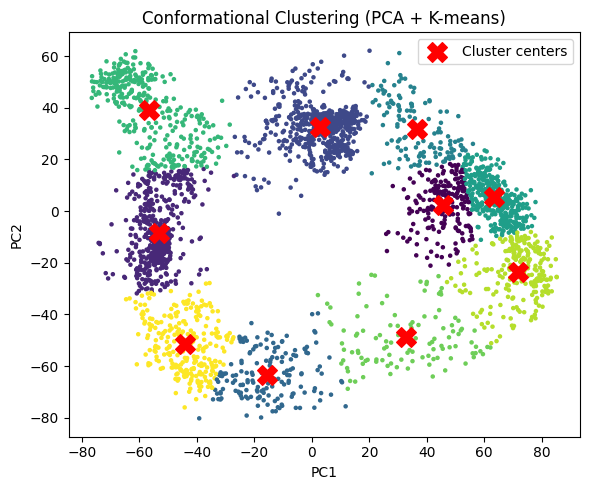

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(pc[:,0], pc[:,1],
            c=labels,
            cmap="viridis",
            s=5)

plt.scatter(centers[:,0], centers[:,1],
            color="red",
            marker="X",
            s=200,
            label ="Cluster centers",

            )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Conformational Clustering (PCA + K-means)")

plt.legend()
plt.tight_layout()

plt.savefig("PCA_clusters.png", dpi=600)

plt.show()

IndexError: list index out of range

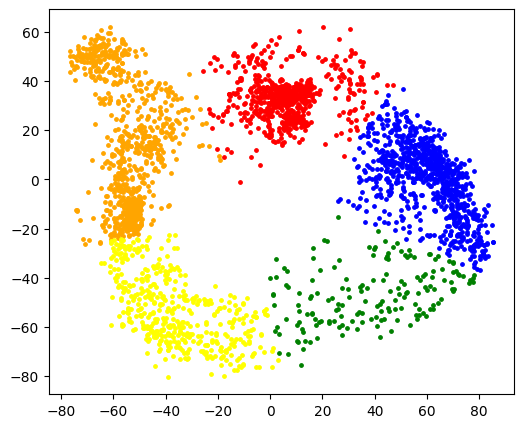

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

# ==============================
# KMEANS
# ==============================

kmeans = KMeans(n_clusters=5, random_state=42)

labels = kmeans.fit_predict(pc)

centers = kmeans.cluster_centers_

# ==============================
# Plot PCA clusters
# ==============================

# cores definidas
colors = ["green", "orange", "red", "blue", "yellow" ]

plt.figure(figsize=(6,5))

for i in range(22):

    cluster_points = pc[labels == i]

    plt.scatter(
        cluster_points[:,0],
        cluster_points[:,1],
        s=6,
        color=colors[i],
        label=f"Cluster {i+1}"
    )


plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Conformational Clustering (PCA + K-means)")

# legenda no canto superior direito
plt.legend(loc="upper right")

plt.tight_layout()

plt.savefig("PCA_clusters.png", dpi=600)

plt.show()

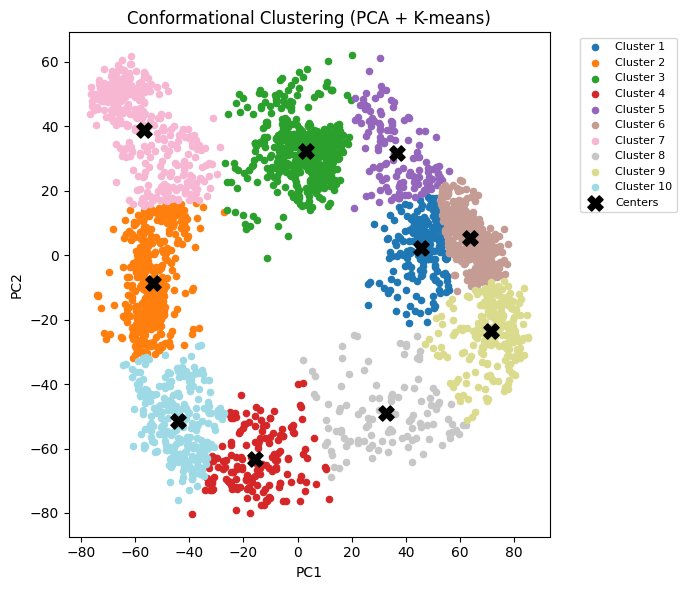

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# ==============================
# KMEANS
# ==============================

n_clusters = 10

kmeans = KMeans(n_clusters=n_clusters, random_state=42)

labels = kmeans.fit_predict(pc)

centers = kmeans.cluster_centers_

# ==============================
# Plot PCA clusters
# ==============================

# gerar 20 cores automaticamente
colors = plt.cm.tab20(np.linspace(0,1,n_clusters))

plt.figure(figsize=(7,6))

for i in range(n_clusters):

    cluster_points = pc[labels == i]

    plt.scatter(
        cluster_points[:,0],
        cluster_points[:,1],
        s=20,
        color=colors[i],
        label=f"Cluster {i+1}"
    )

# centros dos clusters
plt.scatter(
    centers[:,0],
    centers[:,1],
    color="black",
    marker="X",
    s=120,
    label="Centers"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Conformational Clustering (PCA + K-means)")

# legenda (fora do gráfico para não poluir)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=8)

plt.tight_layout()

plt.savefig("PCA_clusters.png", dpi=600)

plt.show()

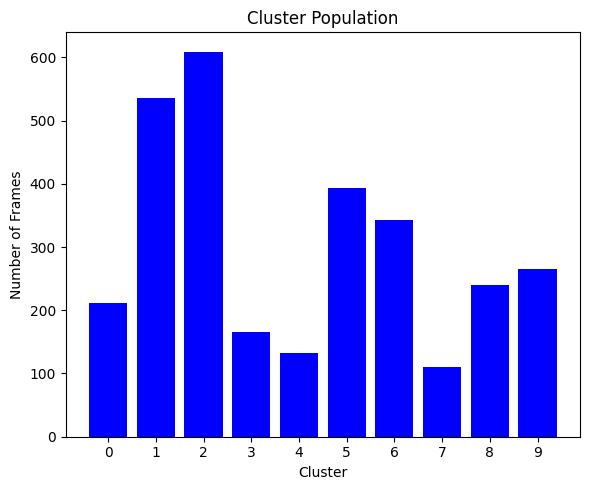

In [ ]:
# ==============================
# BARPLOT DOS CLUSTERS
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# contar frames em cada cluster
cluster_counts = np.bincount(labels)

# número correto de clusters
clusters = np.arange(len(cluster_counts))

plt.figure(figsize=(6,5))

plt.bar(
    clusters,
    cluster_counts,
    color="blue"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Frames")
plt.title("Cluster Population")

plt.xticks(clusters)

plt.tight_layout()

plt.savefig("Cluster_population.png", dpi=600)

plt.show()

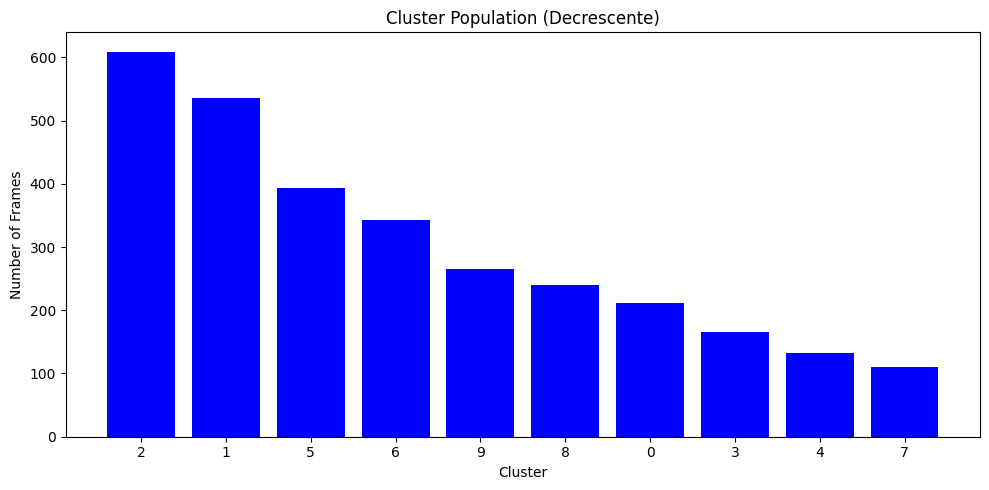

In [ ]:
# ==============================
# BARPLOT DOS CLUSTERS ORDENADO CORRETAMENTE
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# contar frames em cada cluster
cluster_counts = np.bincount(labels)

# números originais dos clusters
clusters = np.arange(len(cluster_counts))

# ordenar os clusters pelo número de frames (decrescente)
sorted_idx = np.argsort(cluster_counts)[::-1]  # índices do maior para o menor
sorted_counts = cluster_counts[sorted_idx]     # valores na ordem decrescente
sorted_clusters = clusters[sorted_idx]         # números dos clusters na ordem

# posições para barras
x_pos = np.arange(len(sorted_counts))

plt.figure(figsize=(10,5))

plt.bar(x_pos, sorted_counts, color="blue")

plt.xlabel("Cluster")
plt.ylabel("Number of Frames")
plt.title("Cluster Population (Decrescente)")

# rótulos corretos
plt.xticks(x_pos, sorted_clusters)

plt.tight_layout()
plt.savefig("Cluster_population_sorted.png", dpi=600)
plt.show()

In [ ]:
import numpy as np

# contar frames em cada cluster
cluster_counts = np.bincount(labels)

# números originais dos clusters
clusters = np.arange(len(cluster_counts))

# ordenar decrescente
sorted_idx = np.argsort(cluster_counts)[::-1]
sorted_counts = cluster_counts[sorted_idx]
sorted_clusters = clusters[sorted_idx]

# população total
total_frames = sorted_counts.sum()

# fração cumulativa
cumulative_fraction = np.cumsum(sorted_counts) / total_frames

# encontrar clusters até 80%
clusters_80pct = sorted_clusters[cumulative_fraction <= 0.8]

# se quiser incluir o cluster que ultrapassa 80% mas ainda contribui
if len(cumulative_fraction) > len(clusters_80pct):
    clusters_80pct = np.append(clusters_80pct, sorted_clusters[len(clusters_80pct)])

print("Clusters que juntos contêm até 80% da população:", clusters_80pct)

Clusters que juntos contêm até 80% da população: [2 1 5 6 9 8 0]


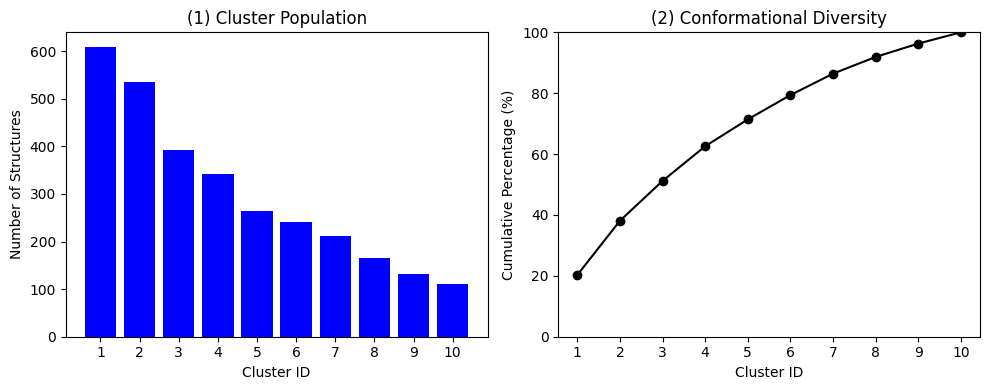

In [ ]:
# ==============================
# CLUSTER POPULATION ANALYSIS
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# número de clusters
n_clusters = 10

# contar estruturas por cluster
cluster_counts = np.bincount(labels, minlength=n_clusters)

# ordenar clusters por população (maior → menor)
sorted_counts = np.sort(cluster_counts)[::-1]

# clusters numerados
clusters = np.arange(1, n_clusters+1)

# porcentagem cumulativa
cumulative_percentage = np.cumsum(sorted_counts) / np.sum(sorted_counts) * 100

# ==============================
# Plot
# ==============================

fig, ax = plt.subplots(1,2, figsize=(10,4))

# (1) Número de estruturas por cluster
ax[0].bar(clusters, sorted_counts, color="blue")
ax[0].set_xlabel("Cluster ID")
ax[0].set_ylabel("Number of Structures")
ax[0].set_title("(1) Cluster Population")
ax[0].set_xticks(clusters)

# (2) Percentual cumulativo
ax[1].plot(clusters, cumulative_percentage, marker="o", color="black")
ax[1].set_xlabel("Cluster ID")
ax[1].set_ylabel("Cumulative Percentage (%)")
ax[1].set_title("(2) Conformational Diversity")
ax[1].set_xticks(clusters)
ax[1].set_ylim(0,100)

plt.tight_layout()

plt.savefig("Cluster_analysis.png", dpi=600)

plt.show()

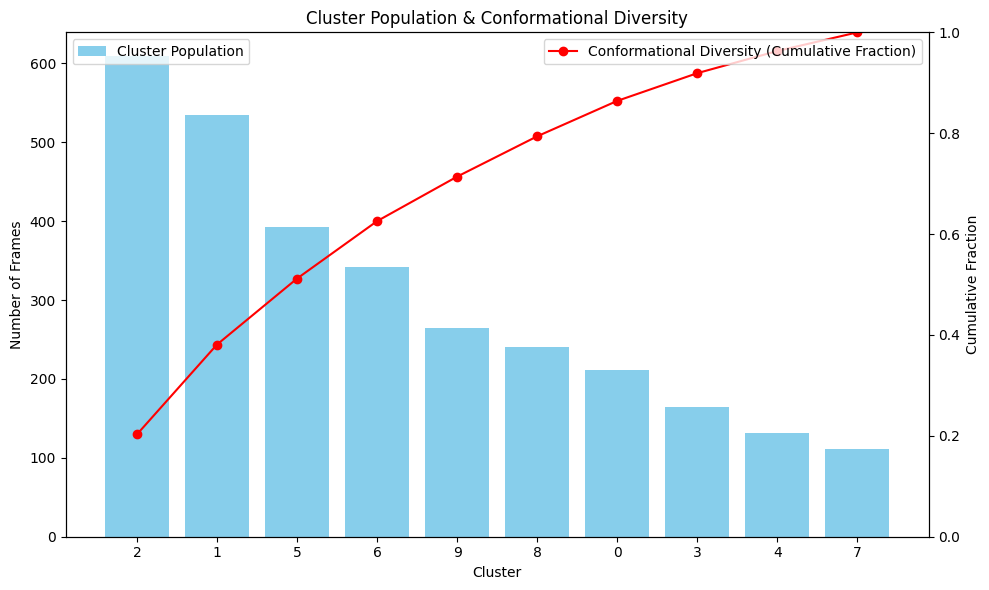

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Preparar dados
# ==============================

# contar frames em cada cluster
cluster_counts = np.bincount(labels)

# números originais dos clusters
clusters = np.arange(len(cluster_counts))

# ordenar decrescente
sorted_idx = np.argsort(cluster_counts)[::-1]
sorted_counts = cluster_counts[sorted_idx]
sorted_clusters = clusters[sorted_idx]

# posições x para as barras
x_pos = np.arange(len(sorted_counts))

# fração cumulativa (Conformational Diversity)
cumulative_fraction = np.cumsum(sorted_counts) / sorted_counts.sum()

# ==============================
# Criar gráfico combinado
# ==============================
fig, ax1 = plt.subplots(figsize=(10,6))

# barra - Cluster Population
bars = ax1.bar(x_pos, sorted_counts, color="skyblue", label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity")

# linha - Conformational Diversity
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Conformational Diversity (Cumulative Fraction)")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# legendas
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("Cluster_population_and_diversity.png", dpi=600)
plt.show()

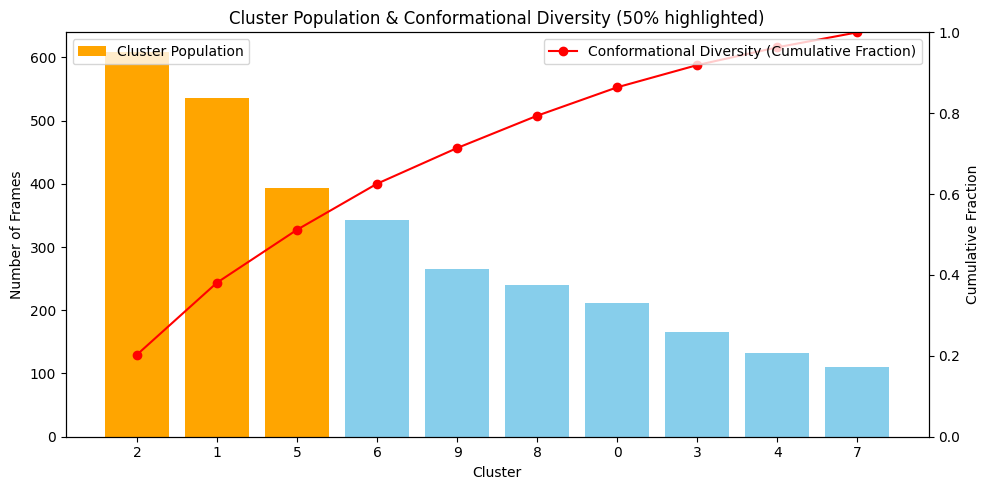

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Preparar dados
# ==============================

# contar frames em cada cluster
cluster_counts = np.bincount(labels)  # assume 12 clusters

# números originais dos clusters
clusters = np.arange(len(cluster_counts))

# ordenar decrescente
sorted_idx = np.argsort(cluster_counts)[::-1]
sorted_counts = cluster_counts[sorted_idx]
sorted_clusters = clusters[sorted_idx]

# posições x para as barras
x_pos = np.arange(len(sorted_counts))

# fração cumulativa (Conformational Diversity)
cumulative_fraction = np.cumsum(sorted_counts) / sorted_counts.sum()

# encontrar clusters que contêm 50% da população (5 primeiros)
idx_50pct = np.where(cumulative_fraction <= 0.5)[0]
if len(cumulative_fraction) > len(idx_50pct):
    idx_50pct = np.append(idx_50pct, len(idx_50pct))  # incluir o cluster que ultrapassa 50%

# ==============================
# Criar gráfico combinado
# ==============================
fig, ax1 = plt.subplots(figsize=(10,5))

# cores: destaque para os clusters que somam 50%
colors = ["orange" if i in idx_50pct else "skyblue" for i in range(len(sorted_counts))]

# barra - Cluster Population
bars = ax1.bar(x_pos, sorted_counts, color=colors, label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity (50% highlighted)")

# linha - Conformational Diversity
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Conformational Diversity (Cumulative Fraction)")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# legendas
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("Cluster_population_diversity_50pct_12clusters.png", dpi=600)
plt.show()

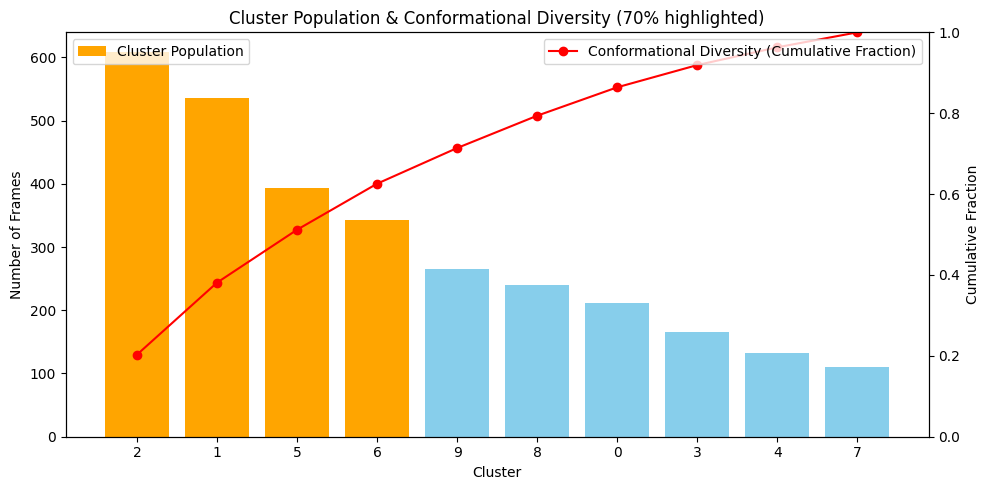

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Preparar dados
# ==============================

# contar frames em cada cluster
cluster_counts = np.bincount(labels)  # assume 10 clusters

# números originais dos clusters
clusters = np.arange(len(cluster_counts))

# ordenar decrescente
sorted_idx = np.argsort(cluster_counts)[::-1]
sorted_counts = cluster_counts[sorted_idx]
sorted_clusters = clusters[sorted_idx]

# posições x para as barras
x_pos = np.arange(len(sorted_counts))

# fração cumulativa (Conformational Diversity)
cumulative_fraction = np.cumsum(sorted_counts) / sorted_counts.sum()

# encontrar clusters que contêm 70% da população
idx_70pct = np.where(cumulative_fraction <= 0.70)[0]
if len(cumulative_fraction) > len(idx_70pct):
    idx_60pct = np.append(idx_70pct, len(idx_70pct))  # incluir o cluster que ultrapassa 50%

# ==============================
# Criar gráfico combinado
# ==============================
fig, ax1 = plt.subplots(figsize=(10,5))

# cores: destaque para os clusters que somam 70%
colors = ["orange" if i in idx_70pct else "skyblue" for i in range(len(sorted_counts))]

# barra - Cluster Population
bars = ax1.bar(x_pos, sorted_counts, color=colors, label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity (70% highlighted)")

# linha - Conformational Diversity
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Conformational Diversity (Cumulative Fraction)")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# legendas
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("Cluster_population_diversity_70pct_12clusters.png", dpi=600)
plt.show()

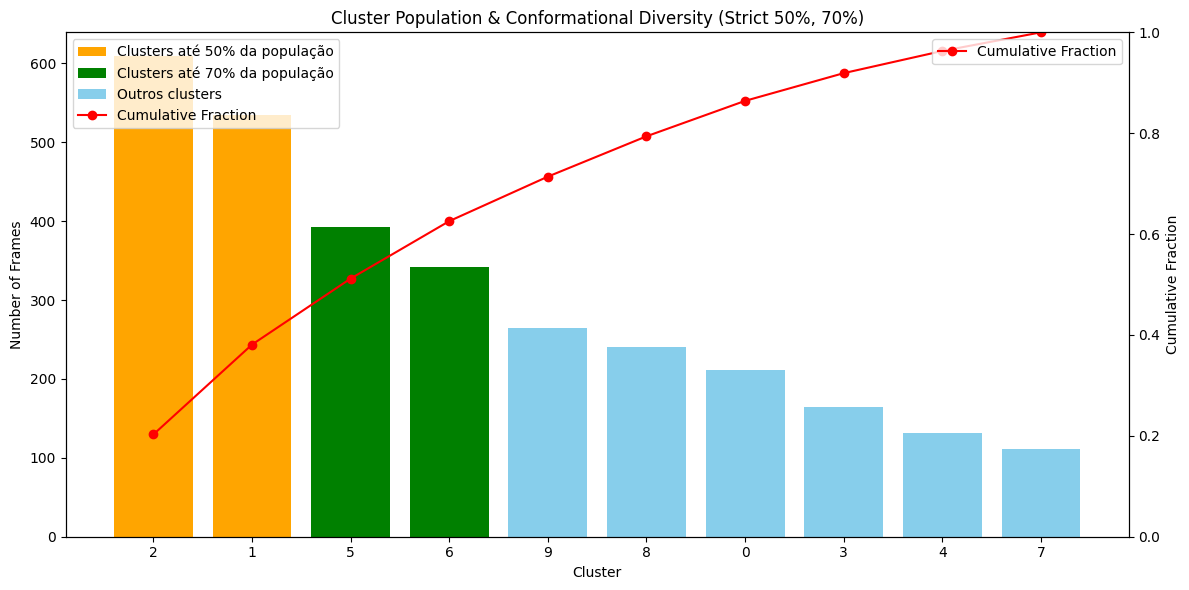

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==============================
# Preparar dados
# ==============================

# contar frames em cada cluster
cluster_counts = np.bincount(labels)  # ajustável conforme número de clusters

# números originais dos clusters
clusters = np.arange(len(cluster_counts))

# ordenar decrescente
sorted_idx = np.argsort(cluster_counts)[::-1]
sorted_counts = cluster_counts[sorted_idx]
sorted_clusters = clusters[sorted_idx]

# posições x para as barras
x_pos = np.arange(len(sorted_counts))

# fração cumulativa (Conformational Diversity)
cumulative_fraction = np.cumsum(sorted_counts) / sorted_counts.sum()

# ==============================
# Determinar clusters dominantes (sem incluir o que ultrapassa a fração)
# ==============================
def get_idx_strict_fraction(fraction):
    # retorna apenas os índices estritamente dentro da fração
    idx = np.where(cumulative_fraction <= fraction)[0]
    return idx

idx_50pct = get_idx_strict_fraction(0.5)
idx_70pct = get_idx_strict_fraction(0.7)

# ==============================
# Definir cores
# ==============================
colors = []
for i in range(len(sorted_counts)):
    if i in idx_50pct:
        colors.append("orange")
    elif i in idx_70pct:
        colors.append("green")
    else:
        colors.append("skyblue")

# ==============================
# Criar gráfico combinado
# ==============================
fig, ax1 = plt.subplots(figsize=(12,6))

# barra - Cluster Population
bars = ax1.bar(x_pos, sorted_counts, color=colors, label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity (Strict 50%, 70%)")

# linha - Conformational Diversity
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Cumulative Fraction")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# legenda personalizada
legend_elements = [
    Patch(facecolor="orange", label="Clusters até 50% da população"),
    Patch(facecolor="green", label="Clusters até 70% da população"),
    Patch(facecolor="skyblue", label="Outros clusters"),
    plt.Line2D([0], [0], color="red", marker="o", label="Cumulative Fraction")
]
ax1.legend(handles=legend_elements, loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("Cluster_population_diversity_strict.png", dpi=600)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda

# ==============================
# 1️⃣ Carregar estruturas
# ==============================

# Ensemble NMR
u_nmr = mda.Universe("syndecan4_NMR__ensemble.pdb")

# Trajetórias MD (réplicas)
replica_files = ["rep1_noPBC.xtc", "rep2_noPBC.xtc", "rep3_noPBC.xtc"]
u_md_replicas = [mda.Universe("topoloy.gro", traj) for traj in replica_files]

In [ ]:
# ==============================
# 2️⃣ Seleção de átomos (apenas proteína)
# ==============================

# Seleção restritiva: CA dos resíduos 1–56, ignorando qualquer ligante
selection = "name CA and resid 1:56 and not resname LIG"

# Átomos de referência do NMR
ref_atoms = u_nmr.select_atoms(selection)

# Verificação rápida: todos os frames devem ter 56 átomos
for i, ts in enumerate(u_nmr.trajectory):
    frame_atoms = u_nmr.select_atoms(selection)
    if len(frame_atoms) != 56:
        raise ValueError(f"Frame {i} não tem 56 átomos CA da proteína, tem {len(frame_atoms)} átomos")

In [ ]:
# ==============================
# 3️⃣ Preparar coordenadas MD de todas as réplicas
# ==============================
coords_list = []
for u in u_md_replicas:
    md_atoms = u.select_atoms(selection)
    for ts in u.trajectory:
        coords_list.append(md_atoms.positions.copy())  # cópia para evitar referência
coords_all = np.array(coords_list)  # shape = (n_md_frames, n_atoms, 3)
n_md_frames = coords_all.shape[0]


In [ ]:
# ==============================
# 4️⃣ Definir clusters MD (substitua pelo seu KMeans real)
# ==============================
# Exemplo placeholder
n_clusters = 5
labels = np.random.randint(0, n_clusters, size=n_md_frames)  # placeholder

In [ ]:
# ==============================
# 5️⃣ Calcular RMSD médio do ensemble NMR vs clusters MD
# ==============================
rmsd_replicas = []

for u in replicas:
    mobile_ca = u.select_atoms("name CA")  # selecionar todos CA da MD
    mobile_atoms = mobile_ca[:56]          # pegar apenas primeiros 56 (protein core)
    print("Átomos MD usados:", len(mobile_atoms))

    rmsd_models = []
    for ts in u_nmr.trajectory:
        R = rms.RMSD(mobile_atoms, ref_atoms=ref_ca[:56], ref_frame=ts.frame)
        R.run()
        rmsd_models.append(R.results.rmsd[:,2])  # RMSD em Å

    rmsd_models = np.array(rmsd_models)
    rmsd_mean_model = rmsd_models.mean(axis=0)
    rmsd_replicas.append(rmsd_mean_model)

rmsd_replicas = np.array(rmsd_replicas)
mean_rmsd = rmsd_replicas.mean(axis=0)
std_rmsd = rmsd_replicas.std(axis=0)

Átomos MD usados: 56
Átomos MD usados: 56
Átomos MD usados: 56


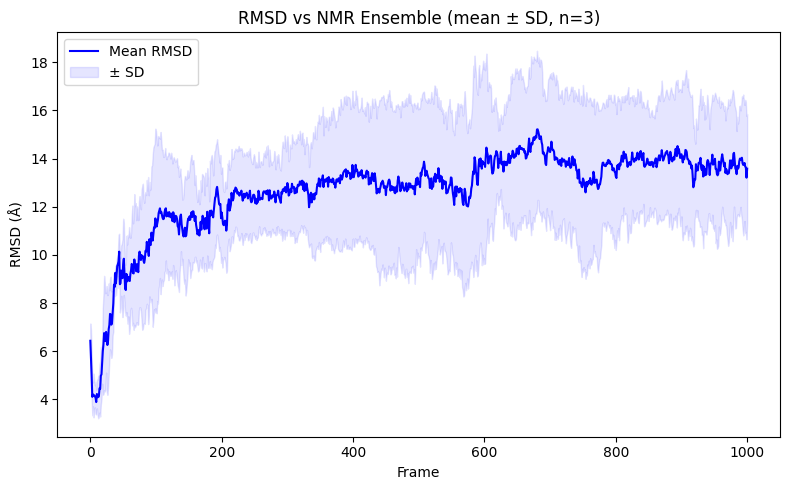

In [ ]:
# ==============================
# 4️⃣ Plot RMSD
# ==============================
plt.figure(figsize=(8,5))
plt.plot(mean_rmsd, color='blue', label='Mean RMSD')
plt.fill_between(range(len(mean_rmsd)),
                 mean_rmsd - std_rmsd,
                 mean_rmsd + std_rmsd,
                 color='blue', alpha=0.1, label='± SD')

plt.xlabel("Frame")
plt.ylabel("RMSD (Å)")
plt.title("RMSD vs NMR Ensemble (mean ± SD, n=3)")
plt.legend()
plt.tight_layout()
plt.savefig("RMSD_vs_NMR_ensemble_corrected.png", dpi=600)
plt.show()

In [ ]:
# ==============================
# 6️⃣ Identificar cluster MD mais próximo de cada modelo NMR
# ==============================
closest_cluster = np.nanargmin(cluster_rmsd, axis=1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import rms

# ==============================
# Carregar arquivos
# ==============================
u_nmr = mda.Universe("syndecan4_NMR__ensemble.pdb")  # ensemble NMR
replica_files = ["rep1_noPBC.xtc", "rep2_noPBC.xtc", "rep3_noPBC.xtc"]
replicas = [mda.Universe("topoloy.gro", traj) for traj in replica_files]

In [ ]:
# ==============================
# Seleção de átomos (CA da proteína)
# ==============================
selection = "name CA and resid 1:56 and not resname LIG"
ref_ca = u_nmr.select_atoms(selection)  # NMR
n_atoms = len(ref_ca)

In [ ]:
# ==============================
# RMSD do ensemble NMR vs cada réplica MD
# ==============================
rmsd_replicas = []

for u in replicas:
    mobile_ca = u.select_atoms(selection)  # MD
    rmsd_models = []

    for ts in u_nmr.trajectory:
        # RMSD frame NMR vs toda trajetória MD
        R = rms.RMSD(mobile_ca, ref_atoms=ref_ca, ref_frame=ts.frame)
        R.run()
        rmsd_models.append(R.results.rmsd[:,2])  # coluna 2 = RMSD em Å

    rmsd_models = np.array(rmsd_models)
    rmsd_mean_model = rmsd_models.mean(axis=0)
    rmsd_replicas.append(rmsd_mean_model)

rmsd_replicas = np.array(rmsd_replicas)
mean_rmsd = rmsd_replicas.mean(axis=0)
std_rmsd = rmsd_replicas.std(axis=0)


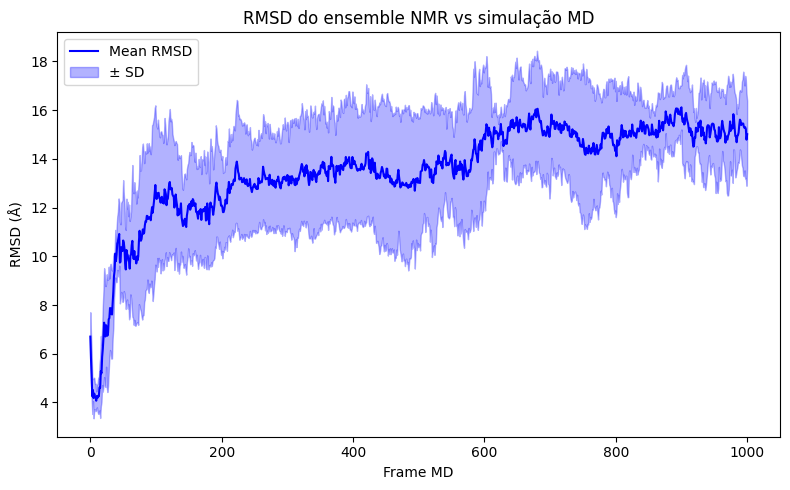

In [ ]:
# ==============================
# Gráfico comparativo
# ==============================
plt.figure(figsize=(8,5))
plt.plot(mean_rmsd, color='blue', label='Mean RMSD')
plt.fill_between(range(len(mean_rmsd)),
                 mean_rmsd - std_rmsd,
                 mean_rmsd + std_rmsd,
                 color='blue', alpha=0.3, label='± SD')
plt.xlabel("Frame MD")
plt.ylabel("RMSD (Å)")
plt.title("RMSD do ensemble NMR vs simulação MD")
plt.legend()
plt.tight_layout()
plt.savefig("RMSD_NMR_vs_MD.png", dpi=600)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from MDAnalysis.analysis import rms
import MDAnalysis as mda
from matplotlib.patches import Patch

# ==============================
# 1️Carregar estruturas
# ==============================
u_nmr = mda.Universe("syndecan4_NMR__ensemble.pdb")
replica_files = ["rep1_noPBC.xtc", "rep2_noPBC.xtc", "rep3_noPBC.xtc"]
replicas = [mda.Universe("topoloy.gro", traj) for traj in replica_files]

In [ ]:
# ------------------------------
# 1️⃣ Seleção de átomos
# ------------------------------
selection = "resid 1:56"
ref_ca = u_nmr.select_atoms(selection)
n_atoms = len(ref_ca)
print(f"NMR atoms selecionados: {n_atoms}")


NMR atoms selecionados: 948


In [ ]:
# ------------------------------
# 2️⃣ Preparar coords_all (MD)
# ------------------------------

# Seleção CA da proteína, ignorando ligante
protein_ca = u_nmr.select_atoms("protein and name CA")
n_atoms = 56  # NMR tem 56 CA

# Selecionar somente os primeiros 56 CA (proteína)
ref_ca = protein_ca[:n_atoms]
print("NMR CA selecionados:", len(ref_ca))

# ----------------------------
# Preparar coords_all (MD)
# ----------------------------
coords_all = []

for u in replicas:
    # Selecionar todos os CA da proteína
    mobile_ca_all = u.select_atoms("protein and name CA")

    # Pegar apenas os primeiros 56 (ignorar ligante)
    mobile_ca = mobile_ca_all[:n_atoms]

    if len(mobile_ca) != n_atoms:
        raise ValueError(
            f"Inconsistência no número de átomos MD: {len(mobile_ca)} != {n_atoms}"
        )

    for ts in u.trajectory:
        coords_all.append(mobile_ca.positions.copy())  # shape (56,3)

coords_all = np.array(coords_all)  # shape: (n_frames_total, 56, 3)
print("Coords_all shape:", coords_all.shape)

NMR CA selecionados: 56
Coords_all shape: (3003, 56, 3)


In [ ]:
# ------------------------------
# 3️⃣ Clustering MD (KMeans)
# ------------------------------
from sklearn.cluster import KMeans

n_clusters = 12
# Flatten coords para KMeans
coords_flat = coords_all.reshape(coords_all.shape[0], n_atoms*3)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(coords_flat)  # array inteiro 0..n_clusters-1

In [ ]:
# ------------------------------
# 4️⃣ Calcular RMSD NMR vs clusters MD
# ------------------------------

cluster_rmsd = np.zeros((len(u_nmr.trajectory), n_clusters))

for i, ts in enumerate(u_nmr.trajectory):
    # NMR frame atual: apenas os 56 CA selecionados
    ref_positions = ref_ca.positions.copy()  # shape (56,3)

    for j in range(n_clusters):
        cluster_indices = np.where(labels == j)[0]
        if len(cluster_indices) == 0:
            cluster_rmsd[i,j] = np.nan
            continue

        # Frames do cluster j: shape (n_frames_cluster, 56,3)
        cluster_frames = coords_all[cluster_indices]

        # RMSD médio do frame NMR vs frames do cluster
        rmsd_values = np.sqrt(np.mean((cluster_frames - ref_positions)**2, axis=(1,2)))
        cluster_rmsd[i,j] = rmsd_values.mean()

print("RMSD médio NMR vs clusters MD calculado com sucesso")

RMSD médio NMR vs clusters MD calculado com sucesso


In [ ]:
# ==============================
# 6️⃣ Determinar qual cluster MD cada modelo NMR se aproxima mais
# ==============================
closest_cluster = np.nanargmin(cluster_rmsd, axis=1)  # array de inteiros 0..n_clusters-1

In [ ]:
# ==============================
# 7️⃣ Preparar dados para o gráfico combinado
# ==============================
cluster_counts = np.bincount(labels, minlength=n_clusters)
clusters = np.arange(n_clusters)

# ordenar clusters por população
sorted_idx = np.argsort(cluster_counts)[::-1]
sorted_counts = cluster_counts[sorted_idx]
sorted_clusters = clusters[sorted_idx]
x_pos = np.arange(len(sorted_counts))

# fração cumulativa
cumulative_fraction = np.cumsum(sorted_counts) / sorted_counts.sum()

# clusters que somam até 50% da população
idx_50pct = np.where(cumulative_fraction <= 0.5)[0]
if len(cumulative_fraction) > len(idx_50pct):
    idx_50pct = np.append(idx_50pct, len(idx_50pct))  # incluir cluster que ultrapassa 50%

# clusters com NMR associado
counts_nmr = np.bincount(closest_cluster, minlength=n_clusters)
nmr_clusters_mask = counts_nmr > 0

# definir cores
colors = []
for i in range(len(sorted_counts)):
    orig_cluster = sorted_clusters[i]
    if i in idx_50pct:
        colors.append("orange")  # Dominantes 50%
    elif nmr_clusters_mask[orig_cluster]:
        colors.append("green")   # NMR associado
    else:
        colors.append("skyblue") # restantes

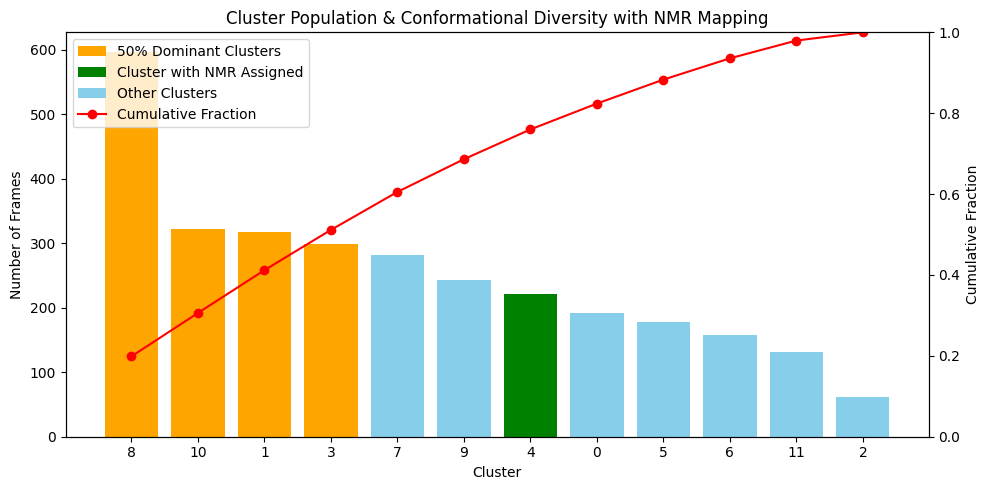

In [ ]:
# ==============================
# 8️⃣ Plot combinado
# ==============================
fig, ax1 = plt.subplots(figsize=(10,5))

bars = ax1.bar(x_pos, sorted_counts, color=colors, label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity with NMR Mapping")

# linha: fração cumulativa
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Cumulative Fraction")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# legenda combinada
legend_elements = [
    Patch(facecolor='orange', label='50% Dominant Clusters'),
    Patch(facecolor='green', label='Cluster with NMR Assigned'),
    Patch(facecolor='skyblue', label='Other Clusters'),
    plt.Line2D([0],[0], color='red', marker='o', label='Cumulative Fraction')
]
ax1.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.savefig("Cluster_population_diversity_NMR_mapping_final.png", dpi=600)
plt.show()

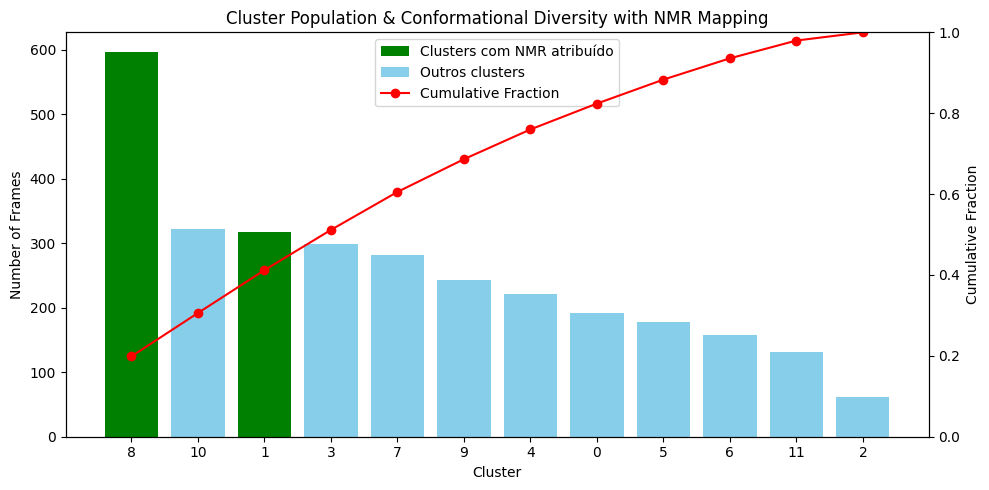

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# --- Dados de exemplo: substituir pelos seus ---
# sorted_counts = contagem de frames por cluster ordenada decrescente
# sorted_clusters = índices dos clusters ordenados
# cumulative_fraction = np.cumsum(sorted_counts) / sum(sorted_counts)
# x_pos = np.arange(len(sorted_counts))
# colors = lista inicial de cores (skyblue)
# clusters com NMR (exemplo)
nmr_clusters = [0, 2]  # substituir pelos clusters que têm NMR atribuído

# ------------------------------
# Definir cores
# ------------------------------

colors = []

for i, frac in enumerate(cumulative_fraction):
    colors.append("skyblue")      # resto

# Destacar clusters com NMR atribuído em verde
for idx in nmr_clusters:
    colors[idx] = "green"

# ------------------------------
# Plot combinado
# ------------------------------
fig, ax1 = plt.subplots(figsize=(10,5))

bars = ax1.bar(x_pos, sorted_counts, color=colors, label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity with NMR Mapping")

# Linha da fração cumulativa
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Cumulative Fraction")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# Legenda combinada
legend_elements = [
    Patch(facecolor='green', label='Clusters com NMR atribuído'),
    Patch(facecolor='skyblue', label='Outros clusters'),
    plt.Line2D([0],[0], color='red', marker='o', label='Cumulative Fraction')
]
ax1.legend(handles=legend_elements, loc="upper center")

plt.tight_layout()
plt.savefig("Cluster_population_diversity_NMR_mapping_final.png", dpi=600)
plt.show()

In [ ]:
# Contar quantas NMR caem em cada cluster
import numpy as np

# --- Contagem de NMR atribuídas a cada cluster ---
nmr_counts = np.bincount(closest_cluster, minlength=n_clusters)  # número de NMR em cada cluster
print("Número de NMR por cluster:", nmr_counts)

# --- Total de frames MD por cluster ---
cluster_counts = np.bincount(labels, minlength=n_clusters)
print("Número total de frames por cluster:", cluster_counts)

# --- Calcular percentual de NMR por cluster ---
# Alguns clusters podem não ter frames MD, então tratamos divisão por zero
percent_nmr = np.zeros(n_clusters)
for i in range(n_clusters):
    if cluster_counts[i] > 0:
        percent_nmr[i] = 100 * nmr_counts[i] / cluster_counts[i]
    else:
        percent_nmr[i] = 0

print("Percentual de NMR por cluster (%):", percent_nmr)

Número de NMR por cluster: [ 0  0  0  0  5  0  0  0 11  0  0  0]
Número total de frames por cluster: [192 318  61 299 221 178 158 282 597 243 322 132]
Percentual de NMR por cluster (%): [0.         0.         0.         0.         2.26244344 0.
 0.         0.         1.84254606 0.         0.         0.        ]


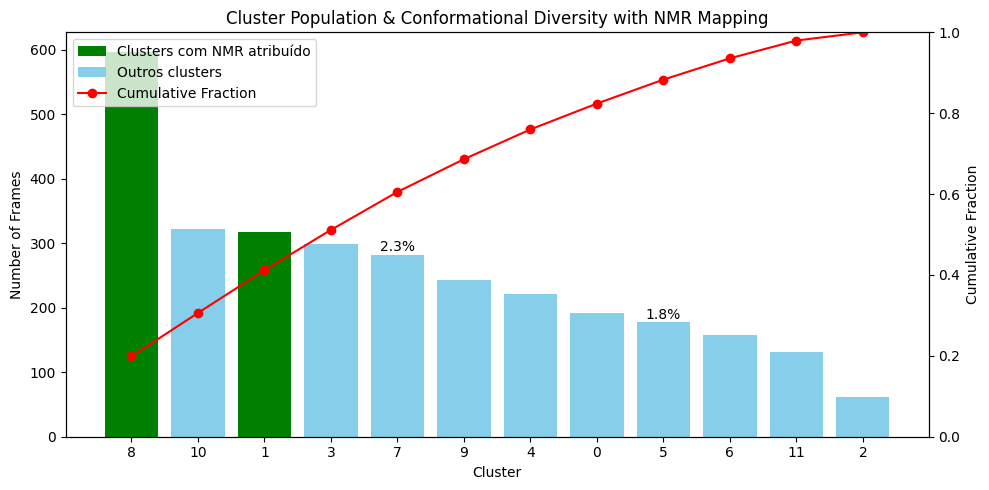

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# --- Dados de exemplo (substituir pelos seus) ---
# sorted_counts = contagem de frames por cluster ordenada decrescente
# sorted_clusters = índices dos clusters ordenados
# cumulative_fraction = np.cumsum(sorted_counts) / sum(sorted_counts)
# x_pos = np.arange(len(sorted_counts))
# percent_nmr = percentual de NMR por cluster calculado antes
# nmr_clusters = índices dos clusters que têm NMR atribuído

# ------------------------------
# Definir cores: destacar clusters com NMR
# ------------------------------
colors = ["green" if i in nmr_clusters else "skyblue" for i in range(len(sorted_counts))]

# ------------------------------
# Plot combinado
# ------------------------------
fig, ax1 = plt.subplots(figsize=(10,5))

bars = ax1.bar(x_pos, sorted_counts, color=colors, label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity with NMR Mapping")

# Adicionar percentual de NMR sobre cada barra
for i, bar in enumerate(bars):
    height = bar.get_height()
    if percent_nmr[i] > 0:  # mostrar apenas clusters com NMR
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                 f"{percent_nmr[i]:.1f}%",
                 ha='center', va='bottom', fontsize=10, color="black")

# Linha da fração cumulativa
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Cumulative Fraction")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# Legenda combinada
legend_elements = [
    Patch(facecolor='green', label='Clusters com NMR atribuído'),
    Patch(facecolor='skyblue', label='Outros clusters'),
    plt.Line2D([0],[0], color='red', marker='o', label='Cumulative Fraction')
]
ax1.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.savefig("Cluster_population_NMR_mapping_percent.png", dpi=600)
plt.show()

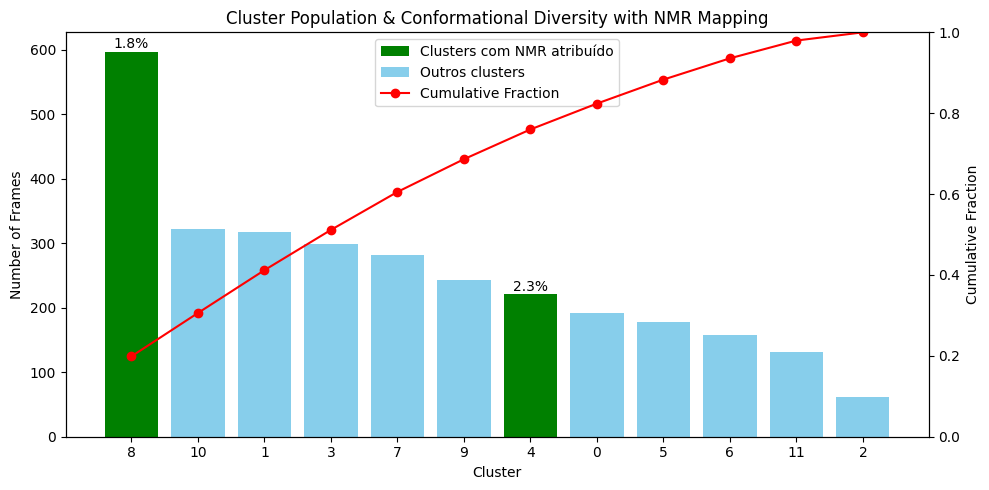

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# --- Dados existentes (substituir pelos seus) ---
# sorted_counts = contagem de frames por cluster ordenada decrescente
# sorted_clusters = índices originais dos clusters ordenados
# cumulative_fraction = np.cumsum(sorted_counts) / sum(sorted_counts)
# x_pos = np.arange(len(sorted_counts))
# percent_nmr = percentual de NMR por cluster (em ordem original)
# n_clusters = número total de clusters

# --- Reorganizar percentuais para a ordem ordenada ---
percent_nmr_sorted = percent_nmr[sorted_clusters]  # alinhando percentuais com sorted_counts

# --- Definir cores: verde para clusters com NMR, azul para outros ---
colors = ["green" if percent_nmr_sorted[i] > 0 else "skyblue" for i in range(len(sorted_counts))]

# Índices originais dos clusters com NMR
nmr_clusters = np.where(percent_nmr > 0)[0]  # todos os clusters que têm NMR

# Definir cores: verde para qualquer cluster com NMR
colors = ["green" if sorted_clusters[i] in nmr_clusters else "skyblue" for i in range(len(sorted_counts))]

# Percentual de NMR alinhado à ordem do gráfico
percent_nmr_sorted = percent_nmr[sorted_clusters]  # para exibir sobre as barras

# ------------------------------
# Plot combinado
# ------------------------------
fig, ax1 = plt.subplots(figsize=(10,5))

bars = ax1.bar(x_pos, sorted_counts, color=colors, label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity with NMR Mapping")

# Adicionar percentual de NMR sobre cada barra verde
for i, bar in enumerate(bars):
    height = bar.get_height()
    if percent_nmr_sorted[i] > 0:  # só para clusters com NMR
        ax1.text(bar.get_x() + bar.get_width()/2,
                 height + 0.5,
                 f"{percent_nmr_sorted[i]:.1f}%",
                 ha='center', va='bottom', fontsize=10, color="black")

# Linha da fração cumulativa
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Cumulative Fraction")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# Legenda combinada
legend_elements = [
    Patch(facecolor='green', label='Clusters com NMR atribuído'),
    Patch(facecolor='skyblue', label='Outros clusters'),
    plt.Line2D([0],[0], color='red', marker='o', label='Cumulative Fraction')
]
ax1.legend(handles=legend_elements, loc="upper center")

plt.tight_layout()
plt.savefig("Cluster_population_NMR_mapping_final.png", dpi=600)
plt.show()

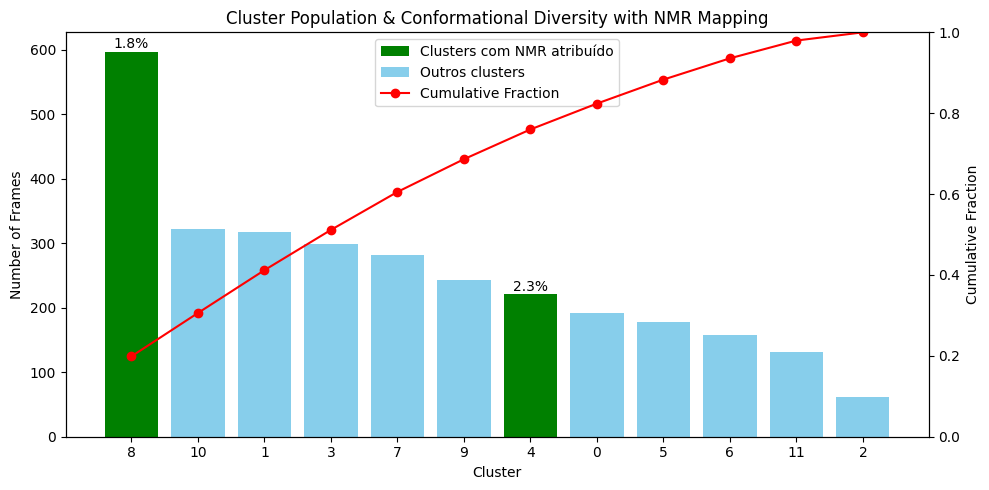

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# --- Dados existentes ---
# sorted_counts: contagem de frames por cluster, do maior para o menor
# sorted_clusters: índices originais dos clusters, na mesma ordem de sorted_counts
# cumulative_fraction: np.cumsum(sorted_counts)/sum(sorted_counts)
# percent_nmr: percentual de NMR por cluster (em ordem original dos clusters)
# x_pos: np.arange(len(sorted_counts))

# --- Identificar clusters que têm NMR ---
nmr_clusters = np.where(percent_nmr > 0)[0]  # índices originais dos clusters com NMR

# --- Definir cores para o gráfico ---
colors = ["green" if sorted_clusters[i] in nmr_clusters else "skyblue" for i in range(len(sorted_counts))]

# --- Percentual alinhado à ordem do gráfico ---
percent_nmr_sorted = percent_nmr[sorted_clusters]

# ------------------------------
# Plot combinado
# ------------------------------
fig, ax1 = plt.subplots(figsize=(10,5))

bars = ax1.bar(x_pos, sorted_counts, color=colors, label="Cluster Population")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Number of Frames")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_clusters)
ax1.set_title("Cluster Population & Conformational Diversity with NMR Mapping")

# Adicionar percentual de NMR sobre cada barra verde
for i, bar in enumerate(bars):
    height = bar.get_height()
    if sorted_clusters[i] in nmr_clusters:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 height + 0.5,
                 f"{percent_nmr_sorted[i]:.1f}%",
                 ha='center', va='bottom', fontsize=10, color="black")

# Linha da fração cumulativa
ax2 = ax1.twinx()
ax2.plot(x_pos, cumulative_fraction, color="red", marker="o", label="Cumulative Fraction")
ax2.set_ylabel("Cumulative Fraction")
ax2.set_ylim(0,1)

# Legenda combinada
legend_elements = [
    Patch(facecolor='green', label='Clusters com NMR atribuído'),
    Patch(facecolor='skyblue', label='Outros clusters'),
    plt.Line2D([0],[0], color='red', marker='o', label='Cumulative Fraction')
]
ax1.legend(handles=legend_elements, loc="upper center")

plt.tight_layout()
plt.savefig("Cluster_population_NMR_mapping_final_corrected.png", dpi=600)
plt.show()

In [ ]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1️⃣ Carregar ensemble NMR
# ==============================
u_nmr = mda.Universe("syndecan4_NMR__ensemble.pdb")

# Seleção de átomos: apenas Cα e resíduos 1 a 56 (ignorar ligante)
selection = "name CA and resid 1:56"
ref_atoms = u_nmr.select_atoms(selection)
n_atoms = len(ref_atoms)
print(f"NMR CA selecionados: {n_atoms}")

NMR CA selecionados: 56


In [ ]:
# ==============================
# 2️⃣ Preparar matriz RMSD
# ==============================
n_models = len(u_nmr.trajectory)
rmsd_matrix = np.zeros((n_models, n_models))


In [ ]:
## ==============================
# 3️⃣ Calcular RMSD entre todos os pares
# ==============================
for i in range(n_models):
    # ir para o frame i
    u_nmr.trajectory[i]
    ref_positions = u_nmr.select_atoms(selection).positions.copy()  # shape (56,3)

    for j in range(i, n_models):
        # ir para o frame j
        u_nmr.trajectory[j]
        mobile_positions = u_nmr.select_atoms(selection).positions.copy()  # shape (56,3)

        # cálculo RMSD
        diff = mobile_positions - ref_positions
        rmsd_val = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        rmsd_matrix[i, j] = rmsd_val
        rmsd_matrix[j, i] = rmsd_val  # simetria

print("Matriz RMSD entre todos os modelos do ensemble NMR calculada.")


Matriz RMSD entre todos os modelos do ensemble NMR calculada.


In [ ]:
# ==============================
# 4️⃣ Estatísticas RMSD
# ==============================
triu_idx = np.triu_indices(n_models, k=1)
mean_rmsd = np.mean(rmsd_matrix[triu_idx])
std_rmsd = np.std(rmsd_matrix[triu_idx])
print(f"RMSD médio entre modelos: {mean_rmsd:.3f} Å ± {std_rmsd:.3f} Å")

RMSD médio entre modelos: 11.880 Å ± 3.457 Å


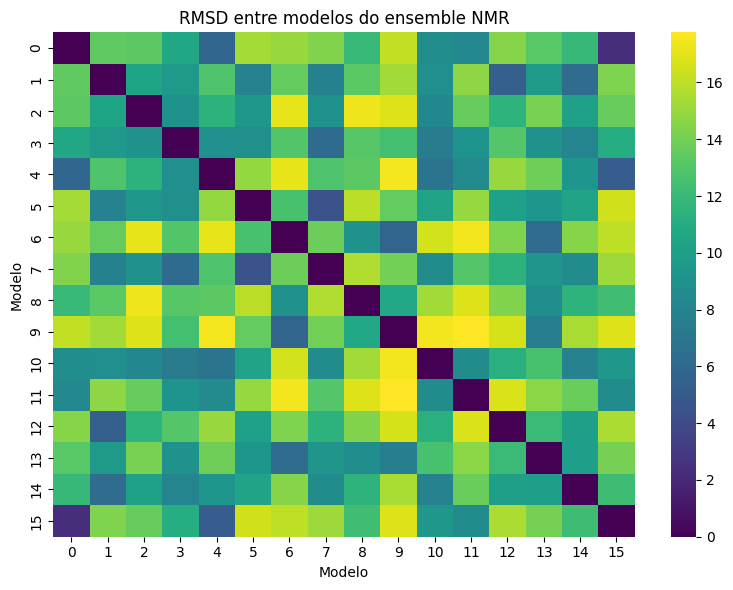

In [ ]:
# ==============================
# 5️⃣ Heatmap da matriz RMSD
# ==============================
plt.figure(figsize=(8,6))
sns.heatmap(rmsd_matrix, cmap="viridis", annot=False)
plt.title("RMSD entre modelos do ensemble NMR")
plt.xlabel("Modelo")
plt.ylabel("Modelo")
plt.tight_layout()
plt.savefig("RMSD_ensemble_heatmap_final.png", dpi=600)
plt.show()

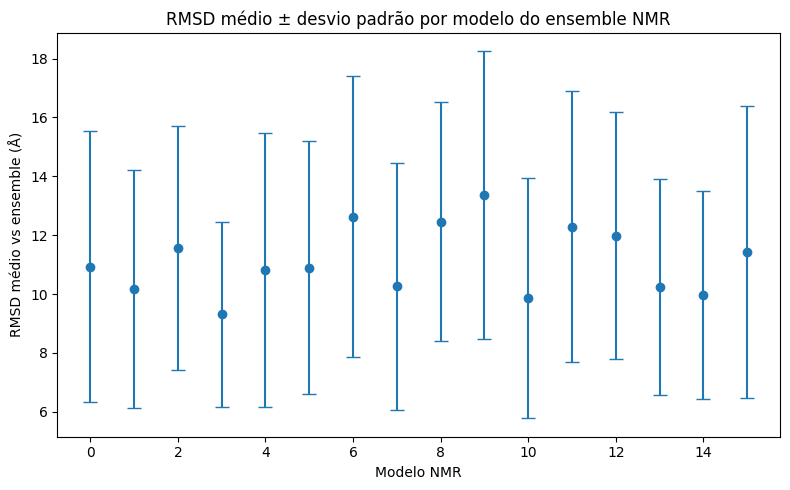

In [ ]:
# ==============================
# 6️⃣ RMSD médio ± desvio padrão por modelo
# ==============================
mean_per_model = np.mean(rmsd_matrix, axis=1)
std_per_model = np.std(rmsd_matrix, axis=1)

plt.figure(figsize=(8,5))
plt.errorbar(np.arange(n_models), mean_per_model, yerr=std_per_model, fmt='o', capsize=5)
plt.xlabel("Modelo NMR")
plt.ylabel("RMSD médio vs ensemble (Å)")
plt.title("RMSD médio ± desvio padrão por modelo do ensemble NMR")
plt.tight_layout()
plt.savefig("RMSD_mean_per_model_final.png", dpi=600)
plt.show()

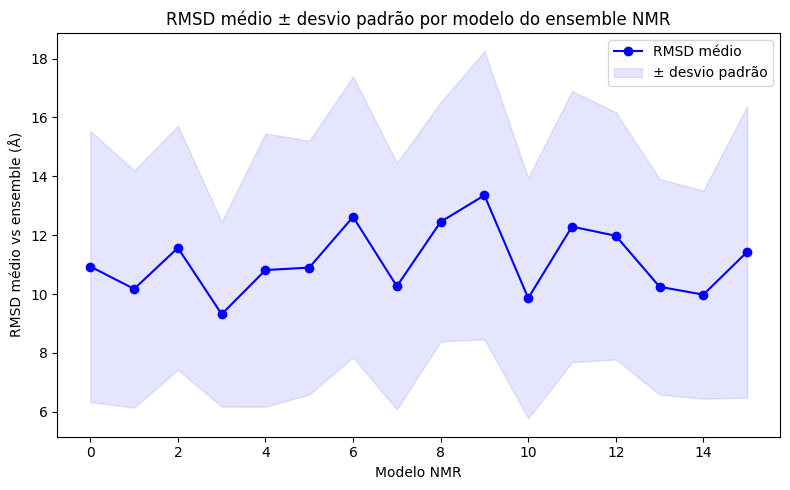

In [ ]:
# ==============================
# 6️⃣ RMSD médio ± desvio padrão por modelo (linha sombreada)
# ==============================
plt.figure(figsize=(8,5))

x = np.arange(n_models)
y = mean_per_model
y_std = std_per_model

# linha média
plt.plot(x, y, color='blue', marker='o', label='Average RMSD')

# sombra ± desvio padrão
plt.fill_between(x, y - y_std, y + y_std, color='blue', alpha=0.1, label='± desvio padrão')

plt.xlabel("Model NMR")
plt.ylabel("Average RMSD vs ensemble (Å)")
plt.title("RMSD médio ± desvio padrão por modelo do ensemble NMR")
plt.legend()
plt.tight_layout()
plt.savefig("RMSD_mean_per_model_shaded.png", dpi=600)
plt.show()

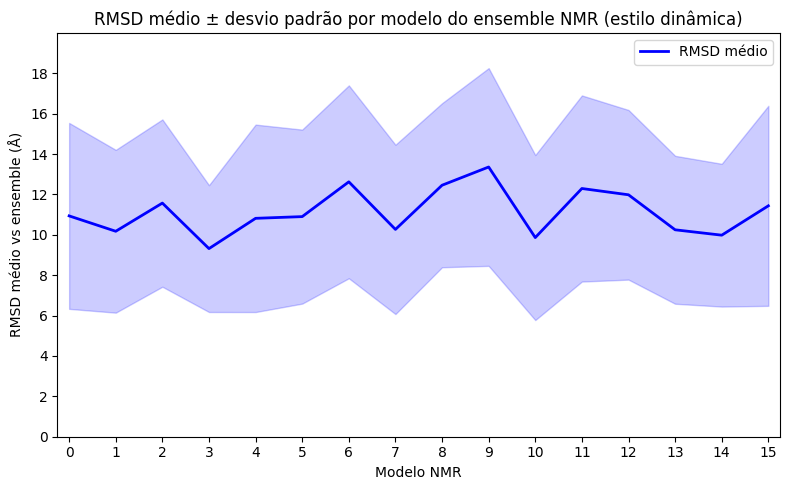

In [ ]:
# ==============================
# 6️⃣ RMSD médio ± desvio padrão por modelo (estilo dinâmica)
# ==============================
plt.figure(figsize=(8,5))

# eixo X: modelo
x = np.arange(n_models)

# linha: RMSD médio
plt.plot(x, mean_per_model, color='blue', linewidth=2, label='Average RMSD')

# sombra: ± desvio padrão
plt.fill_between(
    x,
    mean_per_model - std_per_model,
    mean_per_model + std_per_model,
    color='blue',
    alpha=0.2
)

plt.xlabel("Model NMR")
plt.ylabel("Average RMSD vs ensemble (Å)")
plt.title("RMSD médio ± desvio padrão por modelo do ensemble NMR (estilo dinâmica)")

# limitar escala
plt.xlim(-0.25, 15.25)
plt.ylim(0, 20)  # ajuste conforme o seu RMSD máximo

# Ticks customizados
plt.xticks(np.arange(0, n_models, step=1))
plt.yticks(np.arange(0, 20, step=2))

plt.legend()
plt.tight_layout()
plt.savefig("RMSD_mean_per_model_dynamic_style.png", dpi=600)
plt.show()

In [ ]:
import os

# Diretório onde os arquivos do pipeline foram salvos
folder = "sample_data"

# Lista para armazenar todos os arquivos
arquivos = []

# Percorrer diretório e subdiretórios
for root, dirs, files in os.walk(folder):
    for f in files:
        arquivos.append(os.path.join(root, f))

# Exibir lista
print("Arquivos gerados no diretório 'sample_data':")
for f in arquivos:
    print(f)

Arquivos gerados no diretório 'sample_data':
sample_data/README.md
sample_data/anscombe.json
sample_data/california_housing_train.csv
sample_data/mnist_train_small.csv
sample_data/mnist_test.csv
sample_data/california_housing_test.csv
